# Clase 1: Fundamentos de Redes Neuronales Artificiales (ANN) con TensorFlow

## Caso de Estudio: Clasificación de Flores con Iris Dataset

**Módulo:** Científico de Datos e Inteligencia Artificial Aplicada  
**Tecnologías:** Python, TensorFlow, Scikit-Learn, Jupyter Notebook

## Objetivo de esta práctica simple

Construir una ANN básica para clasificar flores del dataset Iris y entender el flujo completo: datos -> modelo -> entrenamiento -> evaluación -> predicción.

In [13]:
!pip install scikit-learn
!pip install matplotlib

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 1.3 MB/s eta 0:00:06
   ---- ----------------------------------- 0.8/7.8 MB 1.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.0/7.8 MB 1.3 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/7.8 MB 1.2 MB/s eta 0:00:06
   -------- ------------------------------- 1.6/7.8 MB 1.3 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/7.8 MB 1.3 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/7.8 MB 1.3 MB/s eta 0:00:05
   ------------ --------------------------- 2.4/7.8 MB 1.3 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/7.8 MB 1.2 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/7.8 MB 1.3 MB/s eta 0:00:04
   ---------------- ----------------------- 3.1/7.8 MB 1.2 MB/s eta 0:00:04
   ----------------- -----

In [14]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print('TensorFlow:', tf.__version__)

TensorFlow: 2.10.0


In [15]:
# 1) Cargar datos
iris = load_iris()
X = iris.data
y = iris.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Clases:', iris.target_names)

X shape: (150, 4)
y shape: (150,)
Clases: ['setosa' 'versicolor' 'virginica']


In [16]:
# 2) División train/test y escalado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (120, 4) (120,)
Test : (30, 4) (30,)


In [17]:
# 3) Modelo ANN simple
model = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 8)                 40        
                                                                 
 dense_3 (Dense)             (None, 3)                 27        
                                                                 
Total params: 67
Trainable params: 67
Non-trainable params: 0
_________________________________________________________________


In [18]:
# 4) Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

print('Entrenamiento finalizado.')
print('Accuracy train final:', round(history.history['accuracy'][-1], 4))
print('Accuracy val final  :', round(history.history['val_accuracy'][-1], 4))

Entrenamiento finalizado.
Accuracy train final: 0.6979
Accuracy val final  : 0.5833


In [19]:
# 5) Evaluación en test
loss_test, acc_test = model.evaluate(X_test, y_test, verbose=0)
print('Test loss    :', round(loss_test, 4))
print('Test accuracy:', round(acc_test, 4))

Test loss    : 0.6608
Test accuracy: 0.6667


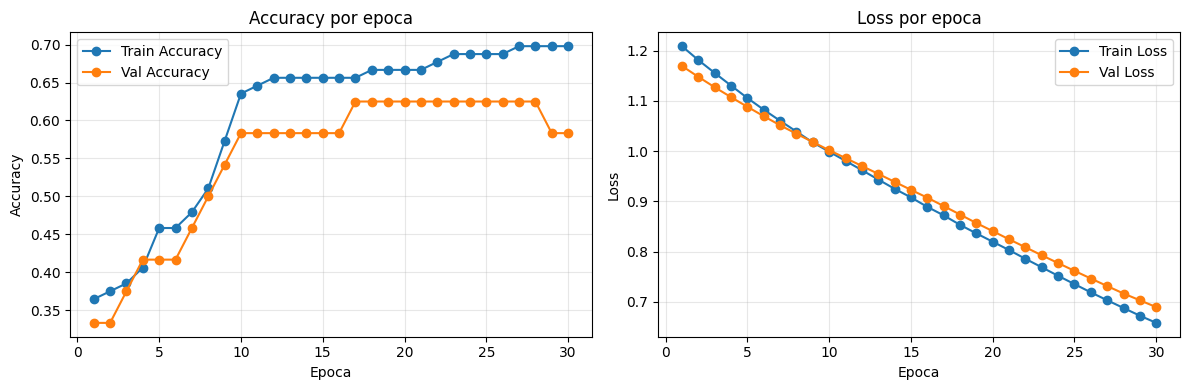

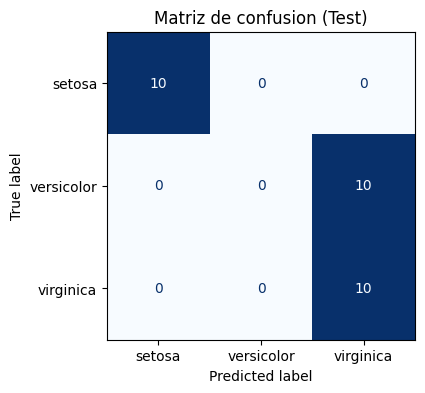

In [20]:
# 5.1) Graficas para evaluar el modelo
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Curvas de entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Val Accuracy')
plt.title('Accuracy por epoca')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.title('Loss por epoca')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Matriz de confusion en test
y_proba_test = model.predict(X_test, verbose=0)
y_pred_test = y_proba_test.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de confusion (Test)')
plt.show()

## Como leer estas graficas

### 1) Curva de Accuracy (entrenamiento vs validacion)
- Si ambas curvas suben y se mantienen cercanas, el modelo aprende bien.
- Si `Train Accuracy` sube mucho pero `Val Accuracy` se estanca o baja, hay **overfitting**.
- Si ambas accuracies se quedan bajas, hay **underfitting** (modelo muy simple o pocas epocas).

### 2) Curva de Loss (entrenamiento vs validacion)
- Lo esperado es que `Train Loss` y `Val Loss` bajen con las epocas.
- Si `Train Loss` baja pero `Val Loss` empieza a subir, el modelo esta memorizando y no generaliza bien.
- El mejor punto suele estar cerca del minimo de `Val Loss`.

### 3) Matriz de confusion (Test)
- Filas: clase real.
- Columnas: clase predicha.
- Valores en la diagonal principal: aciertos.
- Valores fuera de la diagonal: errores de clasificacion.

### Lectura rapida en Iris
- Una diagonal dominante indica buen desempeño.
- Si hay confusion entre clases (por ejemplo Versicolor y Virginica), apareceran valores fuera de la diagonal en esas posiciones.

In [21]:
# 6) Predicción de una muestra real
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample_scaled = scaler.transform(sample)
proba = model.predict(sample_scaled, verbose=0)[0]
pred_class = int(np.argmax(proba))

print('Probabilidades:', np.round(proba, 4))
print('Clase predicha:', iris.target_names[pred_class])

Probabilidades: [0.6976 0.2408 0.0615]
Clase predicha: setosa


## Actividad rápida

1. Cambia `Dense(8)` por `Dense(16)` y compara accuracy.
2. Entrena con `epochs=60` y analiza si mejora o sobreajusta.
3. Prueba una muestra distinta del Iris dataset y revisa la predicción.